<a href="https://colab.research.google.com/github/thrishaa-112/Artificial-Neural-Network/blob/main/Wine_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [2]:
data = load_wine()

X = data.data
y = data.target

print("Shape of data:", X.shape)
print("Target classes:", data.target_names)

Shape of data: (178, 13)
Target classes: ['class_0' 'class_1' 'class_2']


In [3]:
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
model = MLPClassifier(hidden_layer_sizes=(100,),
                      max_iter=500,
                      random_state=42)

In [7]:
model.fit(X_train, y_train)

MLPClassifier(max_iter=500, random_state=42)

In [8]:
y_pred = model.predict(X_test)

In [9]:
sample = X_test[10].reshape(1, -1)

prediction = model.predict(sample)

print("Predicted Wine Class:", prediction[0])

Predicted Wine Class: 0


In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [11]:
f1 = f1_score(y_test, y_pred, average=None)

print("F1 Scores:", f1)

F1 Scores: [1. 1. 1.]


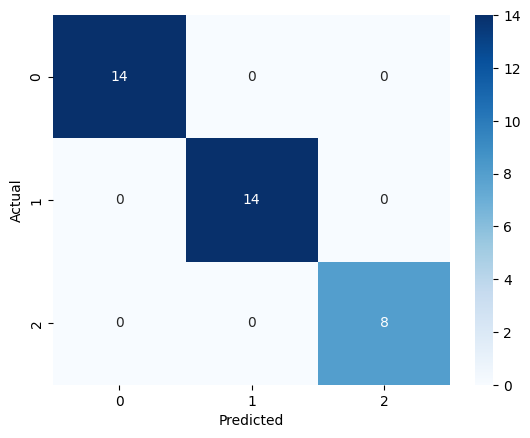

In [12]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()